In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import HDBSCAN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

In [2]:
from matplotlib.colors import XKCD_COLORS

In [3]:
fdf = pd.read_csv("./full_fef_dataset3.csv", header=0, index_col=0)
fdf.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
0,0.0,-0.000021,0.000011,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,-0.000009,0.0,0.0,0.0,1,1,1
1,2.2,-0.000021,0.000021,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,0.000000,0.0,0.0,0.0,1,1,1
2,4.4,-0.000031,0.000011,0.00001,0.000010,-0.000011,-0.000011,-0.000009,0.00001,0.000043,...,0.000000,-0.000072,0.000000,-0.000018,0.0,0.0,0.0,1,1,1
3,6.6,-0.000021,0.000021,0.00000,-0.000010,0.000011,0.000011,0.000000,0.00001,0.000011,...,0.000019,-0.000072,0.000010,0.000026,0.0,0.0,0.0,1,1,1
4,8.8,-0.000042,0.000000,0.00002,0.000031,-0.000033,-0.000021,-0.000019,0.00002,0.000074,...,-0.000019,-0.000072,-0.000019,-0.000061,0.0,0.0,0.0,1,1,1


In [4]:
x = fdf.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = fdf[['indoor', 'outdoor']]

In [5]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [6]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

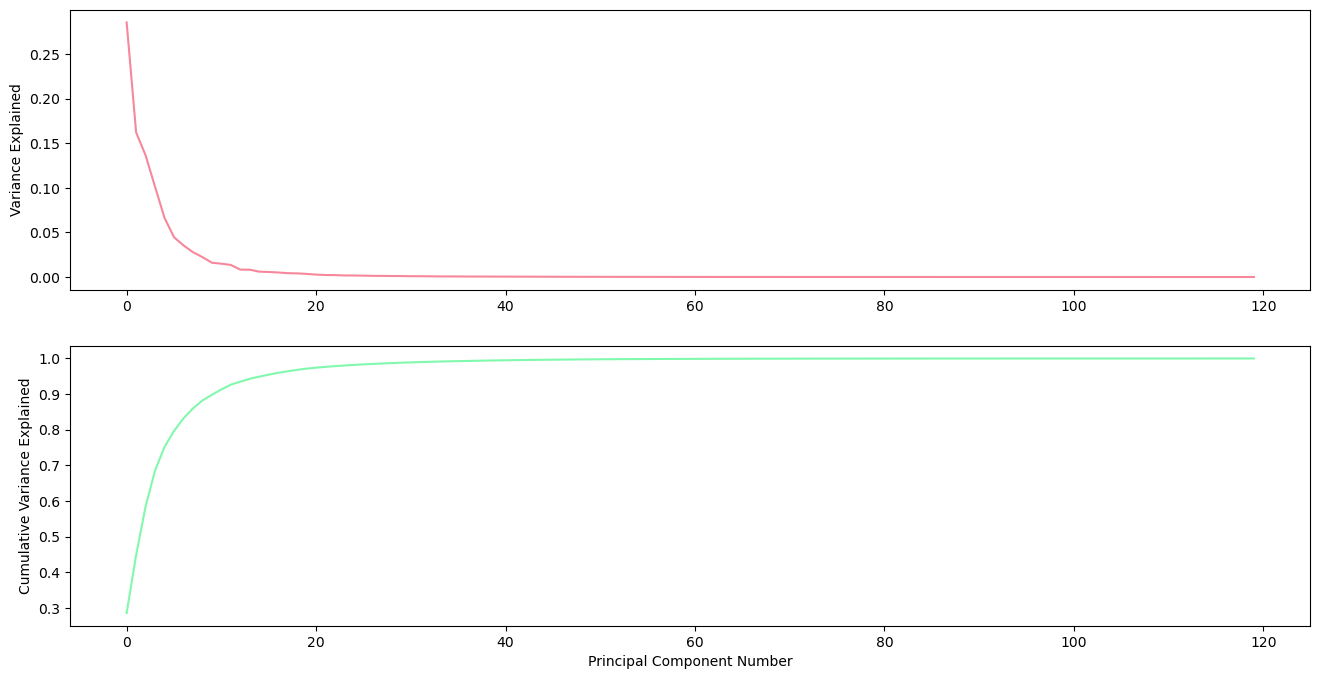

In [7]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

Okay, before moving on to more modeling, let's just take a moment to see if our data actually contain the information we are looking for. We'll do unsupervised learning to get a sense of how separable our data are.

In [8]:
x15pc = pca_x[:,0:15]

Now, this is pretty meaningless to us without an actual visualization, so let's t-sne our way into 3 dimensions so we can take a look.  

In [9]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x15pc)
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time']
tsne_df['Runs'] = fdf['run']
tsne_df['Subjects'] = fdf['subj']
tsne_df['Session'] = fdf['sess']

In [12]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Runs', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Runs")
fig.show(renderer="iframe")

In [13]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subjects")
fig.show(renderer="iframe")

In [17]:
fig = px.scatter_3d(tsne_df[tsne_df['Subjects']==1], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="3D t-SNE of Brain States for Subj 01 by Session")
fig.show(renderer="iframe")

This pretty much proves that what we were seeing (and what all of these algorithms were seeing) is actually just the differences in external variables for each run. We need to get all this into the same space for meaningful analysis. We can do this by standardizing by runs instead of the entire dataset.

In [31]:
for run in fdf['run'].unique():
    idx_run = fdf.index[fdf['run']==run].to_list()
    scaler = StandardScaler()
    x.loc[idx_run,:] = scaler.fit_transform(x.loc[idx_run,:])

In [32]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [33]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

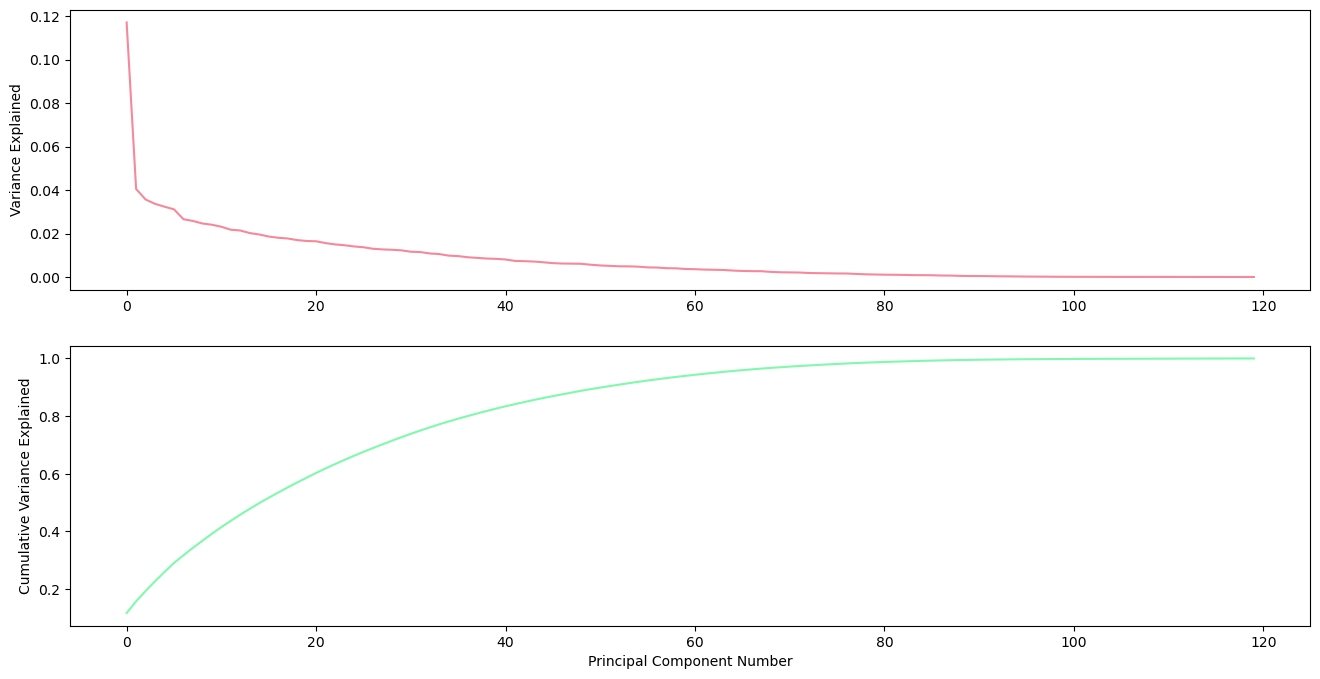

In [34]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [45]:
exp_var[30:35]

array([0.01168037, 0.01152962, 0.01088818, 0.01060297, 0.00988615])

I want to use all principal components that explain 1% or more of the data.

In [47]:
cum_exp_var[34]

np.float64(0.781413924057052)

Altogether, the principal components I've chosen explain about 78% of the variance in the data. This is admittedly not a lot, but let's explore this a bit.

In [48]:
x34pc = pca_x[:,0:34]

In [49]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x34pc)
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time']
tsne_df['Runs'] = fdf['run']
tsne_df['Subjects'] = fdf['subj']
tsne_df['Session'] = fdf['sess']

In [50]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Runs', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Runs")
fig.show(renderer="iframe")

In [51]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subjects")
fig.show(renderer="iframe")

In [53]:
fig = px.scatter_3d(tsne_df[tsne_df['Subjects']==5], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="3D t-SNE of Brain States for Subj 05 by Session")
fig.show(renderer="iframe")

At first, this looked like the same problem as earlier but, after going through a few subjects and their sessions, I've realized something more interesting is going on here: each color is actually separated in space with some chunks in the middle. These...might actually be brain states! 
So we have a different problem now: the sessions are scattered in this sphere. We need to somehow re-align them in a meaningful way. Presumably, one of the strands for a session corresponds to one stimulus and the other to the other stimulus with possibly non-task in the middle. There might be no pattern to how they are rotated: one session's indoor might be another session's outdoor. Our options are to 1) try to work with the data as is by expecting the machine learning algorithm to figure out that distances between data points are artificial/nonlinear, 2) align the runs somehow, 3) use some kind of invariant metadata or latent variables. Let's try option 2 as the idea of the solution is better defined.

In [55]:
fig = px.scatter_3d(tsne_df[tsne_df['Subjects']==3], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="3D t-SNE of Brain States for Subj 03 by Session")
fig.show(renderer="iframe")

In [57]:
fig = px.scatter_3d(tsne_df[tsne_df['Session']==1], x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States for Session 1 by Subjects")
fig.show(renderer="iframe")

What I need to do is find the sessions that had the same sequence of stimuli. Let's go identify the sessions that should have similar activity structures.